In [5]:
import cv2
import numpy as np
from vietocr.tool.predictor import Predictor
from vietocr.tool.config import Cfg
from PIL import Image
import matplotlib.pyplot as plt
import os

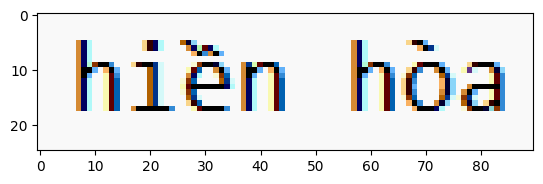

In [6]:
IMAGE_PATH = "anh/image3.png"

if not os.path.exists(IMAGE_PATH):
    raise FileNotFoundError("❌ Không tìm thấy ảnh")

img = Image.open(IMAGE_PATH)

plt.imshow(img)
plt.show(img)


In [7]:
cfg = Cfg.load_config_from_name("vgg_transformer")

cfg["device"] = "cpu"     # đổi thành "cuda" nếu có GPU
cfg["predictor"]["beamsearch"] = True
cfg["cnn"]["pretrained"] = True

vietocr = Predictor(cfg)

Model weight C:\Users\OS\AppData\Local\Temp\vgg_transformer.pth exsits. Ignore download!


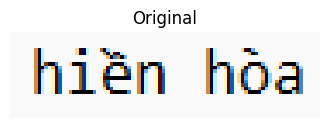

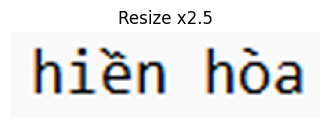

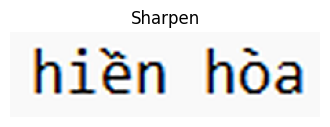

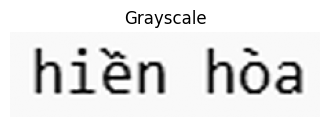

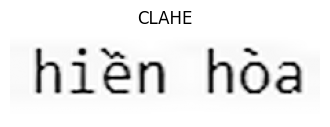

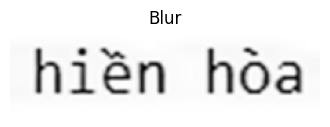

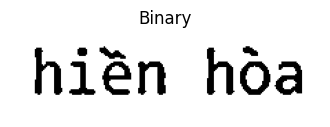

In [9]:
def show(title, img, gray=False):
    plt.figure(figsize=(4,4))
    if gray:
        plt.imshow(img, cmap="gray")
    else:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")
    plt.show()

# 🔹 ĐỌC ẢNH (PIL)
pil_img = Image.open(IMAGE_PATH)

# 🔹 CHUYỂN PIL → OpenCV (BGR)
img = np.array(pil_img)
img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)

# 1️⃣ Ảnh gốc
show("Original", img)

# 2️⃣ Resize (phóng to chữ)
img_resize = cv2.resize(
    img, None,
    fx=2.5, fy=2.5,
    interpolation=cv2.INTER_CUBIC
)
show("Resize x2.5", img_resize)

# 3️⃣ Unsharp Mask (làm nét)
blur = cv2.GaussianBlur(img_resize, (0, 0), 1.0)
img_sharp = cv2.addWeighted(img_resize, 1.5, blur, -0.5, 0)
show("Sharpen", img_sharp)

# 4️⃣ Grayscale
gray = cv2.cvtColor(img_sharp, cv2.COLOR_BGR2GRAY)
show("Grayscale", gray, gray=True)

# 5️⃣ CLAHE
clahe = cv2.createCLAHE(2.0, (8, 8))
gray_clahe = clahe.apply(gray)
show("CLAHE", gray_clahe, gray=True)

# 6️⃣ Blur
gray_blur = cv2.GaussianBlur(gray_clahe, (3, 3), 0)
show("Blur", gray_blur, gray=True)

# 7️⃣ Threshold
binary = cv2.adaptiveThreshold(
    gray_blur, 255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    31, 5
)
show("Binary", binary, gray=True)

In [10]:
text = vietocr.predict(pil_img)

# =========================
# OUTPUT
# =========================
print("\n========== OCR RESULT ==========\n")
print(text.strip())


========== OCR RESULT ==========

hiền hòa


1️⃣ Original → ảnh gốc
2️⃣ Resize → chữ to hơn, rõ hơn
3️⃣ Sharpen → nét chữ sắc
4️⃣ Grayscale → đơn giản hóa dữ liệu
5️⃣ CLAHE → chữ nổi lên
6️⃣ Blur → giảm nhiễu
7️⃣ Binary → chữ / nền tách rõ